<a href="https://colab.research.google.com/github/AshishNalawade0188/Restaurant-Analytics-Predictive-Intelligence-System/blob/main/Karthik/imputed_dataset_KNN_CLASSIFIER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/zomato.csv')

#BASIC EDA

In [3]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [5]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [6]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21
rest_type,227


In [7]:
#df.drop(columns=['url','address','phone','menu_item','location','reviews_list','dish_liked'],inplace=True)


# Finding out continous and categorical columns -> to later do OHE or Label Encoding

In [8]:
categorical = df.columns[df.nunique()<=20]
categorical # will encode using ohe/label depedning on column

Index(['online_order', 'book_table', 'listed_in(type)'], dtype='object')

In [9]:
continous = df.columns[df.nunique()>20]
continous

Index(['url', 'address', 'name', 'rate', 'votes', 'phone', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)',
       'reviews_list', 'menu_item', 'listed_in(city)'],
      dtype='object')

In [10]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

#NAME



In [11]:
df['name'] # no nulls


,name
0,Jalsa
1,Spice Elephant
2,San Churro Cafe
3,Addhuri Udupi Bhojana
4,Grand Village
...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...
51713,Vinod Bar And Restaurant
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...


Online order

In [12]:
# no nulls
df['online_order'].unique()

array(['Yes', 'No'], dtype=object)

book tables

In [13]:
df['book_table'].unique()

array(['Yes', 'No'], dtype=object)

In [14]:
df['book_table'].isna().sum()

np.int64(0)

#rest-type

class sklearn.preprocessing.MultiLabelBinarizer(*, classes=None, sparse_output=False)[source]
Transform between iterable of iterables and a multilabel format.

Although a list of sets or tuples is a very intuitive format for multilabel data, it is unwieldy to process. This transformer converts between this intuitive format and the supported multilabel format: a (samples x classes) binary matrix indicating the presence of a class label.

In [15]:
df['rest_type'].unique() # doohe based on split by comma for clumn values multiple

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', nan, 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Pub, Bar', 'Casual Dining, Pub',
      

If you use MultiLabelBinarizer straight out of the box, you will create a massive matrix of binary (0 and 1) columns. If a restaurant must belong to at least one category, or if certain combinations are highly correlated, your linear regression model's coefficients can become wildly unstable, causing severe overfitting.How to fix it for Regression:Drop One Column (Or use Regularization): If you are using standard Ordinary Least Squares (LinearRegression()), you traditionally drop one of your newly created category columns to serve as the baseline reference point.Switch to Ridge or Lasso: If you keep all the columns generated by the binarizer, do not use basic Linear Regression. Switch to Ridge Regression or Lasso Regression. These variants use L1/L2 regularization to safely handle hundreds of binary encoded columns without crashing your model accuracy.

In [16]:
# Grouped Mode Imputation based on Chi-Square dependency
mode_by_type = df.groupby('listed_in(type)')['rest_type'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
)
print(mode_by_type.unique())

['Casual Dining' 'Cafe' 'Quick Bites' 'Dessert Parlor' 'Bar'
 'Casual Dining, Bar']


In [17]:
df['rest_type'].fillna(mode_by_type,inplace=True)

/tmp/ipykernel_366/1503754775.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rest_type'].fillna(mode_by_type,inplace=True)


In [18]:
df['rest_type'].isna().sum()

np.int64(0)

#Rate COlumn

In [19]:
df['rate']

,rate
0,4.1/5
1,4.1/5
2,3.8/5
3,3.7/5
4,3.8/5
...,...
51712,3.6 /5
51713,NaN
51714,NaN
51715,4.3 /5


In [20]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [21]:
df['rate'] = df['rate'].astype(str).str.split('/').str[0].str.strip()
df['rate'].unique()

array(['4.1', '3.8', '3.7', '3.6', '4.6', '4.0', '4.2', '3.9', '3.1',
       '3.0', '3.2', '3.3', '2.8', '4.4', '4.3', 'NEW', '2.9', '3.5',
       'nan', '2.6', '3.4', '4.5', '2.5', '2.7', '4.7', '2.4', '2.2',
       '2.3', '-', '4.8', '4.9', '2.1', '2.0', '1.8'], dtype=object)

In [22]:
df['rate'] = df['rate'].replace({'NEW': np.nan,'nan': np.nan, '-': np.nan})
df['rate'].isnull().sum()

np.int64(10052)

# errors='coerce' forces pandas to convert valid strings into numbers (floats).
# Any text that cannot be turned into a number (like empty spaces or text phrases) becomes NaN (Not a Number).

In [23]:
df['rate'].value_counts()

,count
rate,
3.9,3972
3.8,3873
3.7,3821
3.6,3316
4.0,3183
4.1,2948
3.5,2784
3.4,2476
3.3,2310


In [24]:

df['rate'] = pd.to_numeric(df['rate'],errors='coerce')
df['rate'].dtype

dtype('float64')

In [25]:
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [26]:
# extracting ratings from reviews column and taking the mean of those ratings as the rating

In [27]:
import ast
import re

def extract_all_reviews_mean(review_list_str):
    """
    Parses reviews_list, extracts EVERY rating present in the list,
    and calculates the overall mean of all ratings for that restaurant.
    """
    if pd.isna(review_list_str) or not isinstance(review_list_str, str):
        return np.nan

    try:
        # Convert stringified list into an actual Python list
        reviews = ast.literal_eval(review_list_str)
        all_ratings = []

        # Iterate over EVERY review entry in the list
        for rev in reviews:
            match = re.search(r'Rated\s*(\d+\.?\d*)', str(rev))
            if match:
                rating_val = float(match.group(1))
                # Restrict to valid rating scale (1.0 to 5.0)
                if 1.0 <= rating_val <= 5.0:
                  all_ratings.append(rating_val)

        # Compute the mean of ALL extracted ratings
        return np.mean(all_ratings) if all_ratings else np.nan
    except Exception:
        return np.nan

# Assuming df['rate'] has already been processed by the `clean_rate` function,
# which handles 'X.X/5', 'NEW', and '-' by converting them to float or np.nan.

# 1. Identify missing 'rate' rows and apply the function across all reviews in 'reviews_list'
missing_rate_mask = df['rate'].isna()
df.loc[missing_rate_mask, 'rate'] = df.loc[missing_rate_mask, 'reviews_list'].apply(extract_all_reviews_mean)

# 2. Fill any remaining NaN values in 'rate' with the overall mean of the 'rate' column.
# This step ensures all NaN values are handled, even if reviews_list couldn't provide a rating.
if df['rate'].isna().any():
    overall_mean_rate = df['rate'].mean()
    df['rate'] = df['rate'].fillna(overall_mean_rate)

# 3. Round the updated ratings to 1 decimal place
df['rate'] = df['rate'].round(1)

print("Filled missing rate values using the mean of ALL reviews in reviews_list and overall mean!")
print(df[['rate', 'reviews_list']].isna().sum())

Filled missing rate values using the mean of ALL reviews in reviews_list and overall mean!
rate            0
reviews_list    0
dtype: int64


In [28]:
df.isna().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,0
votes,0
phone,1208
location,21
rest_type,0


dish_liked

### Imputing Missing Values in `dish_liked`

We will fill the missing values in the `dish_liked` column by grouping the data by `rest_type` and then using the mode (most frequent value) of `dish_liked` within each group. If a group has no mode (e.g., all `dish_liked` values are missing for that `rest_type`), it will be filled with 'Unknown Dish'.

In [32]:
# Grouped Mode Imputation for 'dish_liked' based on 'rest_type'
mode_by_rest_type_dish_liked = df.groupby('rest_type')['dish_liked'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else 'Unknown Dish'
)
df['dish_liked'].fillna(mode_by_rest_type_dish_liked, inplace=True)

print("Missing values in 'dish_liked' after grouped mode imputation:")
print(df['dish_liked'].isnull().sum())

Missing values in 'dish_liked' after grouped mode imputation:
0


/tmp/ipykernel_366/925859135.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dish_liked'].fillna(mode_by_rest_type_dish_liked, inplace=True)


In [31]:
df['dish_liked'].value_counts()

,count
dish_liked,
Biryani,182
Chicken Biryani,73
Friendly Staff,69
Waffles,68
Paratha,57
...,...
"Masala Dosa, Filter Coffee, Curd Rice",1
"Dal Makhani, Galauti Kebab, Dum Biryani, Rasgulla, Fish, Garlic Kheer, Tandoori Broccoli",1
"Pasta, Coffee, Mocktails, Pizza, Sandwiches, Macaroon, Croissants",1


#Votes

In [31]:
df['votes'].nunique()

2328

In [ ]:
df['votes'].unique()

array([ 775,  787,  918, ..., 4957, 2382,  843])

In [ ]:
df['votes'].isna().sum()

np.int64(0)

In [ ]:
df['votes'].count()

np.int64(51490)

In [39]:
df['votes'].value_counts()


,count
votes,
4,1140
6,992
7,872
9,738
11,701
...,...
3215,1
2585,1
2510,1


This helps in reducing the imbalance caused by a large number of zero-vote entries while still retaining a representative sample of them.

In [36]:
zero_votes_df = df[df['votes'] == 0]
non_zero_votes_df = df[df['votes'] != 0]

# Calculate 5% of the zero-vote rows
num_to_keep = int(len(zero_votes_df) * 0.05)

# Randomly sample 5% of the zero-vote rows
sampled_zero_votes_df = zero_votes_df.sample(n=num_to_keep, random_state=42)

# Concatenate the non-zero vote rows with the sampled zero-vote rows
df = pd.concat([non_zero_votes_df, sampled_zero_votes_df])

print(f"Original number of 0 votes: {len(zero_votes_df)}")
print(f"Number of 0 votes preserved: {len(sampled_zero_votes_df)}")
print(f"New total number of rows in DataFrame: {len(df)}")
print("Count of 0 votes in the updated DataFrame:")
print(df[df['votes'] == 0].shape[0])

Original number of 0 votes: 10027
Number of 0 votes preserved: 501
New total number of rows in DataFrame: 42191
Count of 0 votes in the updated DataFrame:
501


approx cost

In [55]:
df['approx_cost(for two people)'].nunique() # keep it continous to maintain precise relationship of data

63

In [56]:
df['approx_cost(for two people)'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '1,100', '1,600', '230',
       '130', '1,700', '1,350', '2,200', '1,400', '2,000', '1,800', nan,
       '1,900', '180', '330', '2,500', '2,100', '3,000', '2,800', '3,400',
       '50', '40', '1,250', '3,500', '4,000', '2,400', '2,600', '1,450',
       '70', '3,200', '240', '6,000', '1,050', '2,300', '4,100', '120',
       '5,000', '3,700', '1,650', '2,700', '4,500', '80'], dtype=object)

In [57]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).replace(',',"")


In [58]:
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'],errors='coerce').astype('Int64')

In [59]:
df['approx_cost(for two people)'].dtypes
df['approx_cost(for two people)'].unique()

<IntegerArray>
[ 800,  300,  600,  700,  550,  500,  450,  650,  400,  900,  200,  750,  150,
  850,  100, <NA>,  350,  250,  950,  199,  230,  130,  180,  330,   50,   40,
   70,  240,  120,   80]
Length: 30, dtype: Int64

In [60]:
df['approx_cost(for two people)'].isna().sum()

np.int64(6921)

In [61]:
df['approx_cost(for two people)'].mean()

np.float64(438.69372589062857)

In [62]:
df['approx_cost(for two people)'].median()

np.float64(400.0)

Because the Mean (416.6) > Median (400) > Mode (300), the dataset is pulled to the right by expensive outliers. A few very high-priced restaurants are inflating the overall average cost, while the vast majority of restaurants cluster around a cheaper price point (300–400).

#Imputing nulls


In [63]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].median()) # median less affected by outliers as compared to mean

In [64]:
df['approx_cost(for two people)'].isna().sum() # No Nulls

np.int64(0)

In [65]:
df.columns


Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)', 'rate_class'],
      dtype='object')

# Cuisines # not useful -> continous, 24 nulls : no need to impute , just drop

In [66]:
df['cuisines'].unique()

array(['North Indian, Mughlai, Chinese', 'Chinese, North Indian, Thai',
       'Cafe, Mexican, Italian', ..., 'Kebab, Chinese, Biryani',
       'North Indian, Fast Food, Burger', 'Tibetan, Chinese'],
      dtype=object)

In [67]:
df['cuisines'].isnull().sum()

np.int64(0)

In [68]:
df['cuisines'] = df['cuisines'].replace(['NaN', 'None', 'null'], np.nan)


In [69]:
# Drop rows where 'column_name' has NaN values
df = df.dropna(subset=['cuisines'])


In [70]:

df['cuisines'].isna().sum()

np.int64(0)

In [71]:
df['cuisines'].count()

np.int64(42177)

listed in type

In [44]:
df['listed_in(type)'].unique()

array(['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

In [45]:
df['listed_in(type)'].isna().sum()

np.int64(0)

listed in city

In [46]:
df['listed_in(city)'].unique()

array(['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur',
       'Brigade Road', 'Brookefield', 'BTM', 'Church Street',
       'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar',
       'Jayanagar', 'JP Nagar', 'Kalyan Nagar', 'Kammanahalli',
       'Koramangala 4th Block', 'Koramangala 5th Block',
       'Koramangala 6th Block', 'Koramangala 7th Block', 'Lavelle Road',
       'Malleshwaram', 'Marathahalli', 'MG Road', 'New BEL Road',
       'Old Airport Road', 'Rajajinagar', 'Residency Road',
       'Sarjapur Road', 'Whitefield'], dtype=object)

In [47]:
df['listed_in(city)'].isna().sum()

np.int64(0)

# Dropping Duplicates

In [48]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [49]:
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9540,https://www.zomato.com/bangalore/blends-juice-...,"Nandi Arcade, Maruthinagar Main Road, Madivala...",Blends Juice Cafe,No,No,3.7,0,+91 9880841111,BTM,Quick Bites,Biryani,"Beverages, Desserts",200,[],[],Delivery,BTM
50659,https://www.zomato.com/bangalore/me-and-my-cak...,"BTP Road, Pattandur Agrahara, Whitefield, Bang...",Me And My Cake,No,No,3.7,0,+91 9036070410,Whitefield,Bakery,Chocolate Cake,"Bakery, Desserts",500,[],[],Delivery,Whitefield
23333,https://www.zomato.com/bangalore/rajdhani-spec...,"42, 18 cross, 24th Main Near Royal School Junc...",Rajdhani Special Chole Bhature,No,No,5.0,0,+91 8860546559,JP Nagar,Quick Bites,Biryani,North Indian,200,"[('Rated 5.0', 'RATED\n Nice place to hangout...",[],Dine-out,JP Nagar
28904,https://www.zomato.com/bangalore/ambur-biryani...,"603, Koramangala 8th Block, Bangalore",Ambur Biryani,Yes,No,3.7,0,+91 7892965997,Koramangala 8th Block,Quick Bites,Biryani,Biryani,200,[],"['Chicken Kabab [100 grams]', 'Kushka Rice', '...",Dine-out,Koramangala 4th Block


In [50]:
df.shape

(42177, 17)

In [51]:
df.drop_duplicates(inplace=True)

In [52]:
df.shape

(42177, 17)

#Encoding Categorical Columns and Scaling Continous Columns Together Using *Column Transformer

A Column Transformer is a data preprocessing tool in machine learning that allows you to apply separate transformations to different columns of your dataset simultaneously.Why Use a Column Transformer?Handles mixed data types: Processes numerical and categorical variables at the same time.Prevents data leakage: Integrates seamlessly into machine learning pipelines.Keeps code clean: Replaces manual, repetitive pandas slicing.

In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [73]:
print(categorical)
print(continous)

Index(['online_order', 'book_table', 'listed_in(type)'], dtype='object')
Index(['url', 'address', 'name', 'rate', 'votes', 'phone', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)',
       'reviews_list', 'menu_item', 'listed_in(city)'],
      dtype='object')


# Read : https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html

#KNN Classifier

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Assuming 'df' is the preprocessed DataFrame from previous steps

# 1. Prepare target variable (y)
# Convert 'rate' to integer for classification by rounding
df['rate_class'] = df['rate'].round().astype(int)
y = df['rate_class']

# 2. Prepare feature matrix (X)
# Define numerical and categorical features based on the latest df columns
numerical_features = ['votes', 'approx_cost(for two people)']
categorical_features = ['online_order', 'book_table', 'rest_type', 'cuisines', 'listed_in(type)', 'listed_in(city)']

# Create a list of all features to be used
X = df[numerical_features + categorical_features]

# Create the preprocessing pipelines for numerical and categorical features
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Create a pipeline with preprocessing and KNN classifier
knn_classifier_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                         ('classifier', KNeighborsClassifier(n_neighbors=5))]) # Using 5 neighbors as default

# Fit the KNN classifier pipeline on the training data
knn_classifier_pipeline.fit(X_train, y_train)

# 5. Evaluate the model
y_pred = knn_classifier_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"KNN Classifier Accuracy: {accuracy:.4f}")

KNN Classifier Accuracy: 0.8593


KNN Classifier Accuracy: 0.8593
KNN Classifier Precision: 0.8570
KNN Classifier Recall: 0.8593
KNN Classifier F1-Score: 0.8568

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         7
           2       0.84      0.50      0.63        62
           3       0.76      0.72      0.74      2246
           4       0.89      0.92      0.91      5992
           5       0.96      0.60      0.74       129

    accuracy                           0.86      8436
   macro avg       0.69      0.55      0.60      8436
weighted avg       0.86      0.86      0.86      8436



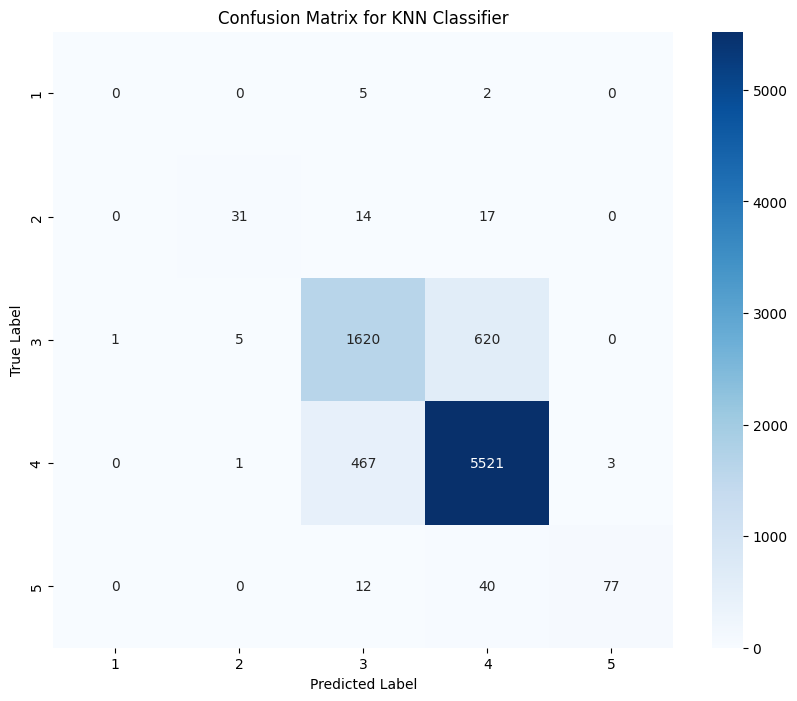

In [75]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming y_test and y_pred are already available from the previous step

# Calculate additional metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"KNN Classifier Accuracy: {accuracy:.4f}")
print(f"KNN Classifier Precision: {precision:.4f}")
print(f"KNN Classifier Recall: {recall:.4f}")
print(f"KNN Classifier F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plotting the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix for KNN Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### What the K-Nearest Neighbors (KNN) Classifier is Doing Here

In this scenario, the K-Nearest Neighbors (KNN) classifier is being used to predict the `rate_class` (the rounded rating of a restaurant, from 1 to 5) for a given restaurant based on its features. Here's a step-by-step breakdown:

1.  **Feature and Target Preparation**: We've identified features (`X`) like `votes`, `approx_cost`, `online_order`, `book_table`, `rest_type`, `cuisines`, `listed_in(type)`, and `listed_in(city)`. The target variable (`y`) is the `rate_class`.

2.  **Preprocessing**: Before KNN can operate effectively, the data is preprocessed:
    *   **Scaling Numerical Features**: `votes` and `approx_cost` are scaled using `StandardScaler`. This is crucial for KNN because it's a distance-based algorithm. If features have vastly different ranges (e.g., votes can be in the thousands, while costs might be hundreds), the features with larger scales would dominate the distance calculation, making the model biased. Scaling ensures all numerical features contribute equally to the 'distance' between restaurants.
    *   **One-Hot Encoding Categorical Features**: Categorical features like `online_order`, `rest_type`, `cuisines`, etc., are converted into a numerical format using `OneHotEncoder`. This creates new binary columns for each unique category, allowing the algorithm to interpret them without imposing arbitrary order (e.g., 'Cafe' is not 'greater than' 'Bar').

3.  **Finding Neighbors**: When predicting the `rate_class` for a new, unseen restaurant, the KNN classifier looks at the `k` (which is 5 in your setup, `n_neighbors=5`) closest restaurants in the training data.

4.  **Voting for a Class**: These 5 closest neighbors 'vote' on the `rate_class` of the new restaurant. The class that receives the most votes (the majority class) among these neighbors is assigned as the predicted `rate_class` for the new restaurant.

In essence, the KNN model is saying: "To predict how this new restaurant will be rated, let's find the 5 most similar restaurants we've seen before (based on votes, cost, type, cuisine, etc.), and whatever rating they mostly have, that's what we'll predict for this new one."

### Comment on Data Imbalance from the Classification Report

The classification report you provided clearly indicates a significant data imbalance, which is a common challenge in real-world datasets. Let's look at the `support` column:

```
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         7
           2       0.84      0.50      0.63        62
           3       0.76      0.72      0.74      2246
           4       0.89      0.92      0.91      5992
           5       0.96      0.60      0.74       129

    accuracy                           0.86      8436
   macro avg       0.69      0.55      0.60      8436
weighted avg       0.86      0.86      0.86      8436
```

**Observations:**

*   **Class 4 Dominance**: The vast majority of your test samples (`5992` out of `8436`) belong to `rate_class 4`. This means the model sees many more examples of restaurants rated 4 than any other rating.
*   **Minority Classes**: Classes `1` (support `7`), `2` (support `62`), and `5` (support `129`) are severely underrepresented. There are very few examples of restaurants with these ratings.

**Impact of Imbalance:**

1.  **Poor Performance on Minority Classes**: The `f1-score` for `rate_class 1` is `0.00`. This means the model completely failed to correctly classify any instance of a restaurant rated 1. For `rate_class 2`, the F1-score is `0.63`, which is much lower than the `0.91` for `rate_class 4`.

2.  **Misleading Accuracy**: While the overall `accuracy` of `0.86` seems good, it's heavily influenced by the model's ability to correctly classify the dominant `rate_class 4`. A model could simply predict `rate_class 4` for almost everything and still achieve high accuracy, but it would be useless for identifying restaurants with low (1, 2) or exceptionally high (5) ratings.

3.  **Macro vs. Weighted Average**: Notice the difference between `macro avg` and `weighted avg` for precision, recall, and F1-score.
    *   `weighted avg` takes class imbalance into account and is closer to your overall accuracy because it's boosted by the dominant class.
    *   `macro avg` treats all classes equally. The `macro avg f1-score` of `0.60` is a much more realistic reflection of your model's performance across *all* classes, highlighting the struggle with minority classes.

**Recommendation**: Given this imbalance, relying solely on accuracy is deceptive. You should consider techniques to address class imbalance if accurately predicting minority classes is important for your problem. These might include:

*   **Resampling Techniques**: Oversampling minority classes (e.g., SMOTE) or undersampling majority classes.
*   **Cost-Sensitive Learning**: Assigning different misclassification costs to different classes.
*   **Using different evaluation metrics**: Prioritizing F1-score, precision, or recall specifically for the minority classes that are most critical.

Here is a structured, high-density summary of your analysis on ColumnTransformer and Scikit-learn Pipelines.
------------------------------
## 📌 Core Verdict
YES, they are highly industry-relevant [1]. They dominate small-to-medium tabular projects, prototyping, and Kaggle (60–70% of tabular ML uses scikit-learn). However, adoption is selective based on engineering trade-offs.
------------------------------
## 🛠️ The 7 Reasons NOT to Use Sklearn Pipelines
When production requirements scale, scikit-learn pipelines encounter structural bottlenecks:
## 1. Data Scale & Performance

* The Issue: Processes data entirely in-memory.
* The Bottleneck: Fails or lags heavily when data exceeds 10GB or requires latency under 5 seconds.
* Alternatives: Apache Spark, Dask, or custom NumPy/Pandas stream processing.

## 2. Complex Feature Dependencies

* The Issue: Pipelines execute steps sequentially and assume independent feature transformations.
* The Bottleneck: Creating a feature that depends on another already-transformed feature leads to unreadable, circular pipeline architectures.
* Alternatives: Custom Python preprocessing functions.

## 3. Model Interpretability & Debugging

* The Issue: Objects encapsulate all intermediate steps.
* The Bottleneck: Inspecting transformed matrices, finding data leaks, or extracting feature importances requires complex, nested syntax (e.g., pipe['preprocessor'].transformers_...).
* Alternatives: Explicit step-by-step transformation scripts.

## 4. Data Leakage Risks

* The Issue: Misconfiguring the pipeline scope introduces data leakage.
* The Bottleneck: Calling fit_transform on a whole dataset before splitting allows test-set metrics (like means or variances) to leak into the training phase.
* Alternatives: Explicit division (fit_transform strictly on train, transform on test).

## 5. Deep Learning Framework Mismatches

* The Issue: Incompatible with non-scikit-learn architectures.
* The Bottleneck: Cannot natively ingest or chain PyTorch, TensorFlow, or Hugging Face transformer models.
* Alternatives: PyTorch DataLoaders or PyTorch Lightning pipelines.

## 6. Static Nature vs. Online Learning

* The Issue: Built for batch training on frozen data.
* The Bottleneck: Cannot handle continuous data streams or real-time model updates without rewriting and retraining the whole pipeline.
* Alternatives: Incremental learning algorithms using partial_fit.

## 7. Team Tech Stack Alignment

* The Issue: Imposes a scikit-learn dependency on the entire team.
* The Bottleneck: Creates friction if data engineers work in Spark, or researchers work exclusively in deep learning ecosystems.
* Alternatives: Standardizing on the team's primary framework.

------------------------------
## 🌲 Architecture Decision Matrix

Dataset > 10GB or Real-Time Stream? ──> YES ──> Use Spark / Dask / Custom Streams
                │
                └─> NO ──> Is it a Deep Learning Model? ──> YES ──> Use PyTorch / TensorFlow
                                 │
                                 └─> NO ──> Complex Feature Interdependencies? ──> YES ──> Use Custom Preprocessing Functions
                                                  │
                                                  └─> NO ──> USE SKLEARN PIPELINES

------------------------------
💡 Next Steps: Would you like me to draft a production-ready Custom Preprocessing Class using scikit-learn's BaseEstimator and TransformerMixin to show how to handle complex feature dependencies safely?



### Evaluating the K-Nearest Neighbors Classifier

Beyond simple accuracy, it's crucial to look at a suite of metrics to understand the full performance profile of a classification model. These metrics include:

*   **Accuracy**: The proportion of correctly classified instances out of the total instances.
*   **Precision**: The proportion of true positive predictions among all positive predictions. It measures the model's ability to avoid false positives.
*   **Recall (Sensitivity)**: The proportion of true positive predictions among all actual positive instances. It measures the model's ability to find all positive samples.
*   **F1-Score**: The harmonic mean of precision and recall. It's a useful metric when you need to balance both precision and recall, especially in cases of imbalanced classes.
*   **Classification Report**: Provides a summary of precision, recall, F1-score, and support for each class.
*   **Confusion Matrix**: A table that describes the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm.